# Signal processign tests

## Setup + helpers

In [5]:
from scipy import fft
import numpy as np
from signal_utils import FTPlotter
import math

ftPlotter = FTPlotter()

In [6]:
def impulse(t: np.ndarray, impulseTime: float):
    x = np.zeros(len(t))
    dt = t[1] - t[0]
    idx = math.floor((impulseTime - t[0]) / dt)
    x[idx] = 1
    return x


def step(t: np.ndarray, stepTime: float):
    x = np.zeros(len(t))
    dt = t[1] - t[0]
    idx = math.floor((stepTime - t[0]) / dt)
    x[idx:] = 1
    return x


def rectPulse(t: np.ndarray, pulseStart: float, pulseEnd: float):
    x = np.zeros(len(t))
    dt = t[1] - t[0]
    startIdx = math.floor((pulseStart - t[0]) / dt)
    endIdx = math.ceil((pulseEnd - t[0]) / dt)
    x[startIdx:endIdx] = 1
    return x


def sinc(t: np.ndarray, centerTime: float, width: float = 1.0):
    return np.sinc((t - centerTime) / width)

## Common DFT pairs

Use helpers to easily create signals and visualize common DFT pairs. 

Notes:
* fft/fftfreq also returns negative frequencies. This is technically redundant since the DFT is periodic i.e. the magnitudes are symmetric with respect to the vertical axis and the phases with respect to the origin at multiples of the nyquist frequency. 

* "Weird" graphs (e.g. DFT{impulse[t]}) on rectagular coordinates are due to the samples falling at different "moments" of the waveform (not perfectly aligned with peaks or troughs); thus when they are connected with lines they look different to the ideal, continuous, fourier transform. There's also the possibility of aliasing, which distorts things further. 

* Phases near t=0 may be a little bit unpredictable sometimes. Ideally, it should be a horizontal line with left-right symmetrical time domain signals. 

In [7]:
N = 256
start = -25
end = 25
t = np.linspace(start, end, N)
dt = t[1] - t[0]
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.rfftfreq.html
# f = fft.rfftfreq(N, d=dt)  # 0 <= f < Nyquist f
f = fft.rfftfreq(N, d=dt) * dt  # 0 <= f < 1/2

print(f"Sampling T = {dt:.2f}, Sampling f = {1/dt:.2f}, Nyquist f = {1/(2*dt):.2f}")

Sampling T = 0.20, Sampling f = 5.10, Nyquist f = 2.55


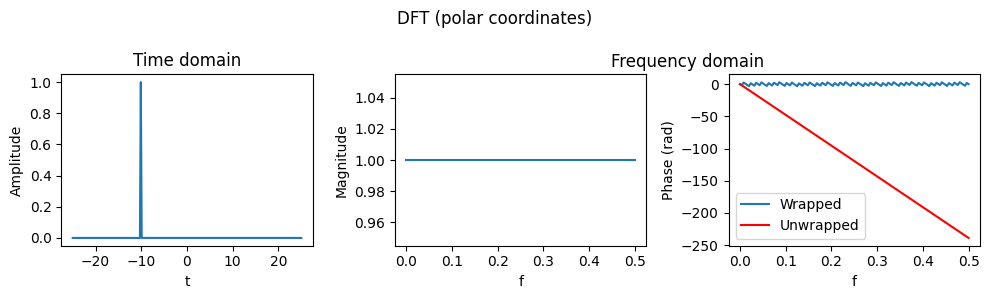

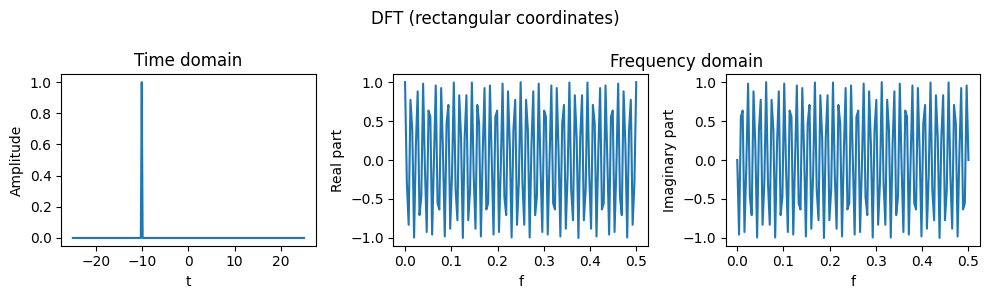

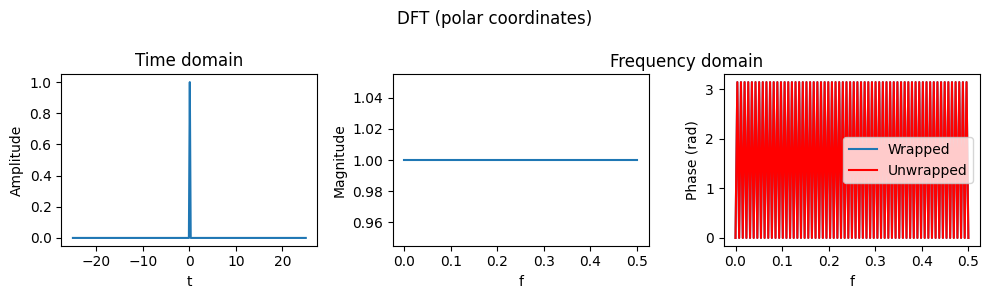

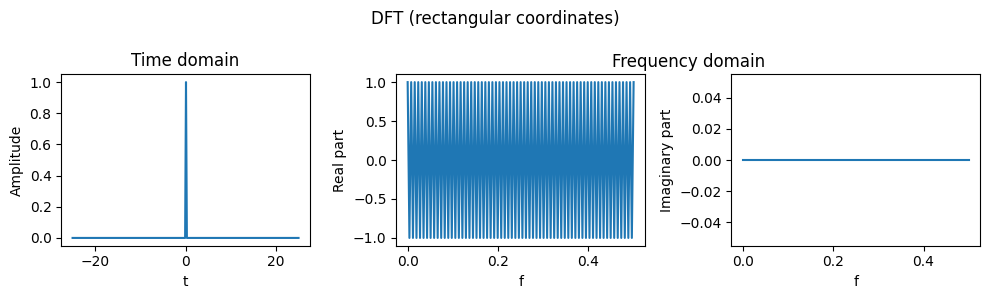

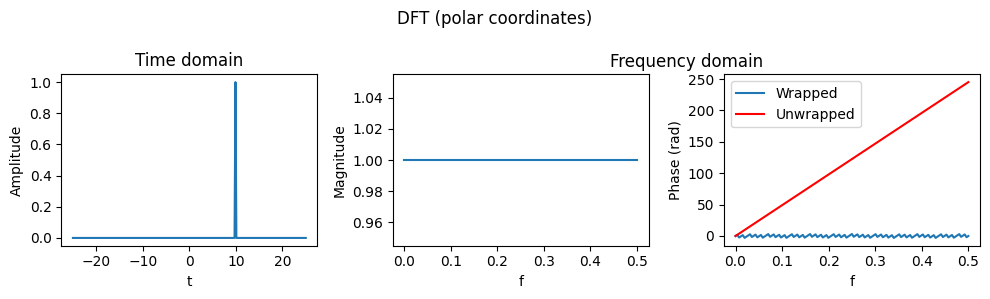

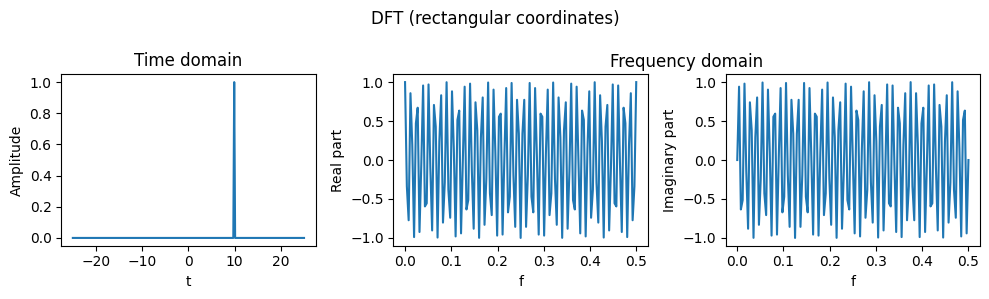

In [ ]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.rfft.html#scipy.fft.rfft

x = impulse(t, -10)
X = fft.rfft(x)
ftPlotter.plotPolar(x, t, X, f)
ftPlotter.plotRect(x, t, X, f)

x = impulse(t, 0.25)
X = fft.rfft(x)
ftPlotter.plotPolar(x, t, X, f)
ftPlotter.plotRect(x, t, X, f)

x = impulse(t, 10)
X = fft.rfft(x)
ftPlotter.plotPolar(x, t, X, f)
ftPlotter.plotRect(x, t, X, f)